In [9]:
import astropy.io.fits as fits
import astropy.units as u
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import aplpy
import astropy.wcs.wcs as wcs
import glob
import os
import pandas as pd
import spectral_cube

import warnings
warnings.filterwarnings("ignore")

from create_figs import cut_fig, create_fig, mark_sources

In [3]:
source_info = pd.read_csv("../data/output/source_info.csv")
source_info.set_index('Main', inplace=True)
target_name = "HOPS-168"
output_path = f"../results/m0_maps/{target_name}_m0.pdf"
file = "/Volumes/Alpha/Research/data/hops-168/hops-168__s15__12co.fits"
target_info = source_info.loc[target_name]

INFO: Auto-setting vmin to -8.727e-02 [aplpy.core]
INFO: Auto-setting vmax to  2.972e-01 [aplpy.core]


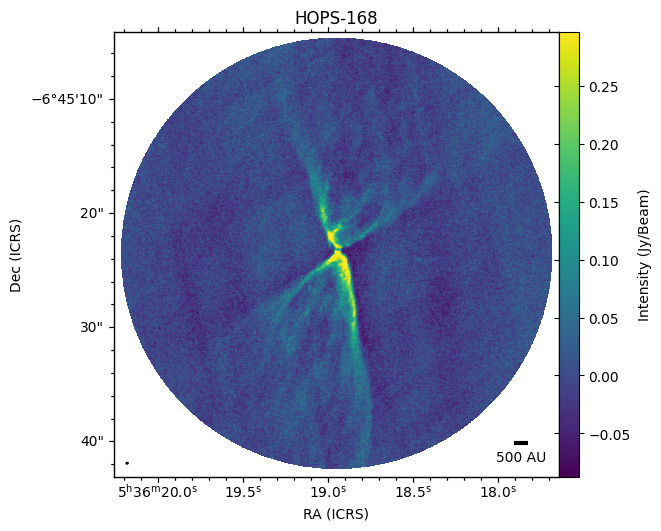

In [ ]:
hdulist = fits.open(file)
hdu = hdulist[0]

# extract center coords
center_ra = hdu.header['OBSRA']
center_dec = hdu.header['OBSDEC']

# set center and size of cutout
center = SkyCoord(center_ra, center_dec, unit=u.degree)
size = np.array([39, 39]) * u.arcsecond
distance = target_info['Dis'].iloc[0]

# create map
channel_idx = np.r_[91:98, 104:115]
channels = hdu.data[0,channel_idx,:,:]
cube = spectral_cube.spectral_cube(channels)

m0_map = np.sum(channels, axis=0)

cut = cut_fig(m0_map, hdu.header, center, size)
    
fig = create_fig(cut, distance)
fig

In [29]:
cube = spectral_cube.SpectralCube(channels, wcs.WCS(hdu.header).dropaxis(3))
m0 = cube.moment(order=0)

INFO: Auto-setting vmin to -6.395e+04 [aplpy.core]
INFO: Auto-setting vmax to  1.914e+05 [aplpy.core]


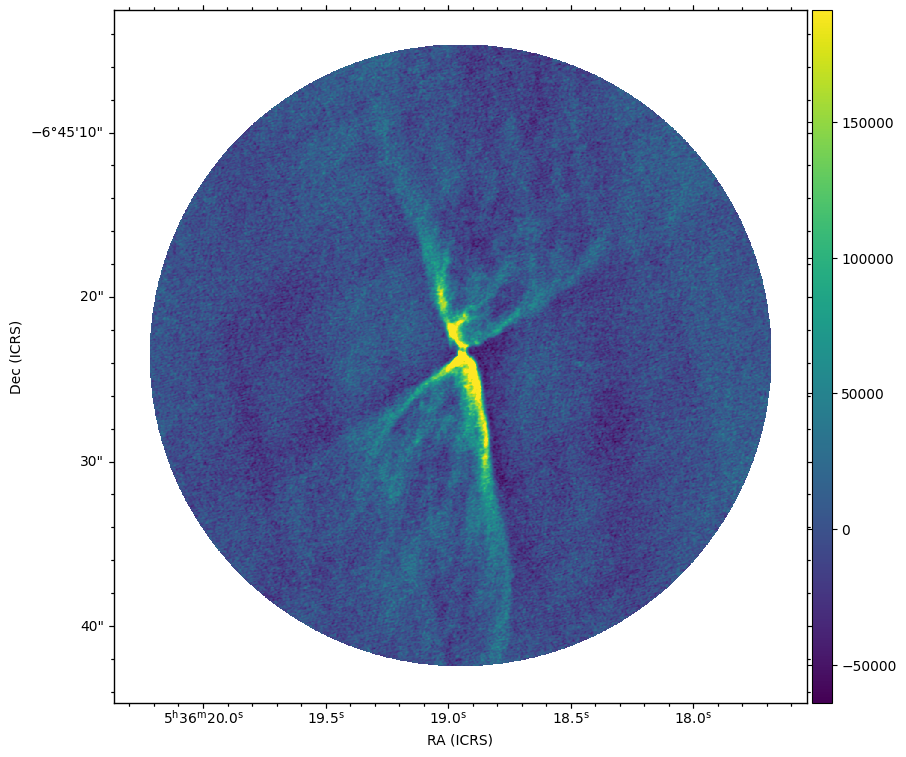

In [42]:
fig = aplpy.FITSFigure(m0.hdu)
fig.show_colorscale()
fig.add_colorbar()